# compare CIE mice to DO and HP mice

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import re

from scipy.stats import ttest_ind

import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 180

In [2]:
def parse_lcmodel_directory(directory_path):
    """
    Parse LCModel output files in a directory into a pandas DataFrame.
    
    Parameters:
    directory_path (str): Path to directory containing LCModel output files
    
    Returns:
    pd.DataFrame: Parsed data with metabolite concentrations and metadata
    """
    
    # Define the target columns
    columns = ['mouse_ID', 'brain_region', 'date', 'TE', 'timepoint', 'series_number',
               'Ala_Conc', 'Ala_over_Cr', 'Ala_SD',
               'Asp_Conc', 'Asp_over_Cr', 'Asp_SD',
               'GABA_Conc', 'GABA_over_Cr', 'GABA_SD',
               'Gln_Conc', 'Gln_over_Cr', 'Gln_SD',
               'Glu_Conc', 'Glu_over_Cr', 'Glu_SD',
               'GPC_Conc', 'GPC_over_Cr', 'GPC_SD',
               'Ins_Conc', 'Ins_over_Cr', 'Ins_SD',
               'Lac_Conc', 'Lac_over_Cr', 'Lac_SD',
               'NAA_Conc', 'NAA_over_Cr', 'NAA_SD',
               'Tau_Conc', 'Tau_over_Cr', 'Tau_SD',
               'GPC_p_PCh_Conc', 'GPC_p_PCh_over_Cr', 'GPC_p_PCh_SD',
               'NAA_p_NAAG_Conc', 'NAA_p_NAAG_over_Cr', 'NAA_p_NAAG_SD',
               'Cr_p_PCr_Conc', 'Cr_p_PCr_over_Cr', 'Cr_p_PCr_SD']
    
    # Collect all row data first
    all_rows = []
    
    # Get all files ending with "_tab"
    directory = Path(directory_path)
    tab_files = [f for f in directory.iterdir() if f.name.endswith('_tab')]
    
    for file_path in tab_files:
        try:
            # Parse filename to extract metadata
            filename = file_path.stem  # Remove path, keep filename without extension
            
            # Extract mouse_ID and brain_region
            if filename.endswith('_tab'):
                base_name = filename[:-4]  # Remove '_tab'
            else:
                base_name = filename
                
            # Parse mouse_ID (DO + number + letter)
            mouse_match = re.match(r'(DO[1-4][A-F])', base_name)
            if not mouse_match:
                print(f"Warning: Could not parse mouse_ID from {filename}")
                continue
                
            mouse_id = mouse_match.group(1)
            
            # Extract brain region (everything after mouse_ID)
            brain_region = base_name[len(mouse_id):]
            
            # Parse the LCModel file
            metabolite_data = parse_lcmodel_file(file_path)
            
            if metabolite_data is None:
                print(f"Warning: Could not parse data from {filename}")
                continue
            
            # Create row data
            row_data = {
                'mouse_ID': mouse_id,
                'brain_region': brain_region,
                'date': None,  # You might need to extract this from file metadata or filename
                'TE': None,    # Extract from file content if available
                'timepoint': None,
                'series_number': None
            }
            
            # Add metabolite data
            row_data.update(metabolite_data)
            
            # Add to list
            all_rows.append(row_data)
            
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            continue
    
    # Create DataFrame from all rows at once
    if all_rows:
        df = pd.DataFrame(all_rows, columns=columns)
    else:
        df = pd.DataFrame(columns=columns)
    
    return df

def parse_lcmodel_file(file_path):
    """
    Parse a single LCModel output file to extract metabolite concentrations.
    
    Parameters:
    file_path (Path): Path to the LCModel output file
    
    Returns:
    dict: Dictionary containing metabolite data
    """
    
    metabolite_data = {}
    
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        
        # Find the concentration table section
        conc_match = re.search(r'\$\$CONC.*?lines in following concentration table.*?\n(.*?)(?=\$\$|\Z)', content, re.DOTALL)
        
        if not conc_match:
            return None
        
        conc_section = conc_match.group(1)
        
        # Parse each line in the concentration table
        lines = conc_section.strip().split('\n')
        
        # Skip header line if present
        data_lines = [line for line in lines if line.strip() and not line.strip().startswith('Conc.')]
        
        for line in data_lines:
            # Parse line format: "    2.038  14%   0.235 Ala"
            parts = line.split()
            if len(parts) >= 4:
                try:
                    conc = float(parts[0])
                    sd_str = parts[1].rstrip('%')
                    sd = float(sd_str) if sd_str != '999' else None
                    over_cr = float(parts[2])
                    metabolite = parts[3]
                    
                    # Map metabolite names to column names
                    metabolite_mapping = {
                        'Ala': 'Ala',
                        'Asp': 'Asp', 
                        'GABA': 'GABA',
                        'Gln': 'Gln',
                        'Glu': 'Glu',
                        'GPC': 'GPC',
                        'Ins': 'Ins',
                        'Lac': 'Lac',
                        'NAA': 'NAA',
                        'Tau': 'Tau',
                        'GPC+PCh': 'GPC_p_PCh',
                        'NAA+NAAG': 'NAA_p_NAAG',
                        'Cr+PCr': 'Cr_p_PCr'
                    }
                    
                    if metabolite in metabolite_mapping:
                        base_name = metabolite_mapping[metabolite]
                        metabolite_data[f'{base_name}_Conc'] = conc
                        metabolite_data[f'{base_name}_over_Cr'] = over_cr
                        metabolite_data[f'{base_name}_SD'] = sd
                        
                except (ValueError, IndexError) as e:
                    continue
        
        return metabolite_data
        
    except Exception as e:
        print(f"Error parsing file {file_path}: {str(e)}")
        return None

In [3]:
#HP_path = Path(r'/home/eb/Documents/FPA2_acerS3/AIRC/INIAstress/PV_mice_results/HP_DS_and_VS_061925.xlsx')
HP_path = Path(r'C:\Users\baetscer\Downloads\OneDrive_1_8-22-2025\HP_DS_and_VS_061925.xlsx')

#CIE_path = Path(r'/home/eb/Documents/FPA2_acerS3/AIRC/INIAstress/PV_mice_results/CIE_FSS_MRS_data_w_DCZ_20250606_2.xlsx')
CIE_path = Path(r'C:\Users\baetscer\Downloads\OneDrive_1_8-22-2025\CIE_FSS_MRS_data_w_DCZ_20250606_2.xlsx')

#DO_LCM_output_path = Path(r'/home/eb/Documents/FPA2_acerS3/AIRC/INIAstress/DO_PARC_mice/DO_mice_2024_LCM_output_1/LCM_output_1')

#DO_spreadsheet_path = Path(r'/home/eb/Documents/FPA2_acerS3/AIRC/INIAstress/PV_mice_results/DO_mice_MRS_results_20250820.xlsx')
DO_spreadsheet_path = Path(r'C:\Users\baetscer\Downloads\OneDrive_1_8-22-2025\DO_mice_MRS_results_20250820.xlsx')

Literature_Chassain_2010_path = Path(r'C:\Users\baetscer\Downloads\OneDrive_1_8-22-2025\Mouse_MRS_lit_MPTP_Chassain_2010_02.xlsx')

Metabolic changes detected in vivo by 1H MRS in the MPTP-intoxicated mouse
Carine Chassain, Guy Bielicki, Cécile Keller, Jean-Pierre Renou, Franck Durif
First published: 16 July 2010
https://doi.org/10.1002/nbm.1504
Citations: 32

Table 1. Concentrations of brain metabolites quantified in this study (Baetscher, et al., 2025, Addiction Biology) and in a previous publication in striatum (a) and in cortex (b) of the same mouse strain, C57Bl6/J Data were the mean ± SD for eight animals in our four groups and for seven animals in the study of Tkac (Tkac et al., 2004) in the striatum (a) and for six animals in the cortex (b).
a.
STRIATUM 	Metabolites concentrations (mM)
Groups (n = 8) 	tCho 	GABA 	Glu 	Gln 	Lac 	Myo-Ins 	NAA 	Tau 	tCr
Controls + saline 	1.4 ± 0.1 	1.6 ± 0.2 	11.4 ± 0.9 	2.0 ± 0.6 	4.1 ± 0.7 	4.5 ± 0.4 	6.5 ± 0.6 	14.5 ± 0.9 	8.6 ± 0.3
Controls + levodopa 	1.3 ± 0.1 	1.8 ± 0.3 	11.2 ± 0.4 	2.0 ± 0.5 	4.4 ± 0.7 	4.1 ± 0.4 	6.6 ± 0.3 	14.4 ± 0.9 	8.6 ± 0.5
MPTP + saline 	1.2 ± 0.1 	3.6 ± 0.8 	20.2 ± 0.8 	5.4 ± 1.6 	3.9 ± 0.6 	5.1 ± 0.7 	6.9 ± 0.5 	14.6 ± 0.6 	8.6 ± 0.5
MPTP + levodopa 	1.1 ± 0.1 	1.7 ± 0.4 	11.2 ± 0.4 	1.6 ± 0.4 	4.6 ± 0.5 	4.0 ± 0.4 	6.3 ± 0.4 	14.3 ± 1.2 	8.6 ± 0.7
Tkac et a.l, 2004 (n = 7) 	1.4 ± 0.1 	2.7 ± 0.3 	 8.9 ± 0.4 	3.7 ± 0.4 	4.6 ± 0.5 	4.1 ± 0.4 	7.1 ± 0.3 	12.3 ± 0.9 	8.0 ± 0.6

In [4]:
HP_df = pd.read_excel(HP_path)

CIE_df = pd.read_excel(CIE_path)

Lit_Chassain_2010_df = pd.read_excel(Literature_Chassain_2010_path)

In [5]:
#DO_df = parse_lcmodel_directory(DO_LCM_output_path)

DO_df = pd.read_excel(DO_spreadsheet_path)

In [6]:

# Parse the directory
#DO_df = parse_lcmodel_directory(DO_LCM_output_path)

## Display results
#print(f"Parsed {len(df)} files")
#print(f"DataFrame shape: {df.shape}")
#print("\nFirst few rows:")
#print(DO_df.head())

DO_df.head()

,Unnamed: 0,mouse_ID,brain_region,date,TE,timepoint,series_number,Ala_Conc,Ala_over_Cr,Ala_SD,...,Tau_SD,GPC_p_PCh_Conc,GPC_p_PCh_over_Cr,GPC_p_PCh_SD,NAA_p_NAAG_Conc,NAA_p_NAAG_over_Cr,NAA_p_NAAG_SD,Cr_p_PCr_Conc,Cr_p_PCr_over_Cr,Cr_p_PCr_SD
0,0,DO2D,ventral_striatum,NaN,NaN,NaN,NaN,1.449,0.155,20.0,...,5,3.034,0.325,2,9.428,1.010,3,9.336,1,2
1,1,DO3D,mPFC,NaN,NaN,NaN,NaN,6.056,0.410,10.0,...,5,6.211,0.421,3,19.082,1.293,3,14.761,1,3
2,2,DO2B,dorsal_striatum,NaN,NaN,NaN,NaN,2.083,0.275,11.0,...,3,2.740,0.361,2,7.631,1.007,3,7.580,1,2
3,3,DO2C,ventral_striatum,NaN,NaN,NaN,NaN,1.026,0.122,28.0,...,4,3.049,0.361,3,7.871,0.933,4,8.441,1,2
4,4,DO2B,ventral_striatum,NaN,NaN,NaN,NaN,1.555,0.180,16.0,...,4,3.203,0.371,2,7.300,0.846,3,8.629,1,2


In [7]:
#DO_df.to_excel('DO_mice_MRS_results_20250820.xlsx')

In [8]:
#DO_df

In [9]:
#HP_df

In [10]:
#for col_a in CIE_df.columns:
#    print(col_a)

CIE_df.head()

,mouse_ID,date_BL,Ala_Conc_BL,Ala_over_Cr_BL,Ala_SD_BL,Asp_Conc_BL,Asp_over_Cr_BL,Asp_SD_BL,GABA_Conc_BL,GABA_over_Cr_BL,...,GPC_p_PCh_over_Cr_postDCZ_minus_preDCZ,NAA_p_NAAG_Conc_postDCZ_minus_preDCZ,NAA_p_NAAG_over_Cr_postDCZ_minus_preDCZ,Cr_p_PCr_Conc_postDCZ_minus_preDCZ,Cr_p_PCr_over_Cr_postDCZ_minus_preDCZ,glu_over_GABA_postDCZ_minus_preDCZ,glu_over_GABA_Conc_postDCZ_minus_preDCZ,glu_over_gln_postDCZ_minus_preDCZ,include_in_DREADD_analysis,include_in_MRS_analysis
0,PV01,20230320,2.918535,0.217,37,1.604503,0.119,64,2.077303,0.155,...,-0.022,0.433214,0.010,0.492149,0,-1.340499,-1.337637,-0.021623,no,no
1,PV03,20230320,2.349319,0.298,19,4.797736,0.608,21,2.815338,0.357,...,-0.030,-0.202476,0.050,-0.569028,0,2.169151,2.159058,0.215947,no,no
2,PV04,20230322,1.745196,0.061,98,18.396024,0.641,12,0.000000,0.000,...,-0.021,-0.389737,-0.027,-0.294166,0,-0.413779,-0.418590,-0.170630,no,no
3,PV05,20230322,0.000000,0.000,999,0.428401,1.284,16,0.000000,0.000,...,-0.032,-0.968222,-0.031,-1.016914,0,0.503143,0.503475,-0.013598,no,no
4,PV06,20230322,4.508036,0.203,20,3.944476,0.177,46,3.483664,0.157,...,-0.021,-0.000887,-0.023,0.161788,0,-0.525895,-0.522914,-0.140820,no,yes


In [11]:
CIE_df.drop(CIE_df.index[[0, 1, 2, 4]], inplace=True)

In [12]:
CIE_df.head()

,mouse_ID,date_BL,Ala_Conc_BL,Ala_over_Cr_BL,Ala_SD_BL,Asp_Conc_BL,Asp_over_Cr_BL,Asp_SD_BL,GABA_Conc_BL,GABA_over_Cr_BL,...,GPC_p_PCh_over_Cr_postDCZ_minus_preDCZ,NAA_p_NAAG_Conc_postDCZ_minus_preDCZ,NAA_p_NAAG_over_Cr_postDCZ_minus_preDCZ,Cr_p_PCr_Conc_postDCZ_minus_preDCZ,Cr_p_PCr_over_Cr_postDCZ_minus_preDCZ,glu_over_GABA_postDCZ_minus_preDCZ,glu_over_GABA_Conc_postDCZ_minus_preDCZ,glu_over_gln_postDCZ_minus_preDCZ,include_in_DREADD_analysis,include_in_MRS_analysis
3,PV05,20230322,0.000000,0.000,999,0.428401,1.284,16,0.000000,0.000,...,-0.032,-0.968222,-0.031,-1.016914,0,0.503143,0.503475,-0.013598,no,no
5,PV07,20230405,0.520791,0.252,37,1.084162,0.526,25,0.333156,0.162,...,-0.014,0.103116,0.139,-0.865633,0,-0.894772,-0.895966,-0.188111,yes,yes
6,PV08,20230405,0.418152,0.175,24,1.005070,0.420,24,0.246046,0.103,...,-0.005,0.360827,0.041,0.143730,0,-0.128205,-0.126382,-0.079843,no,yes
7,PV09,20230405,0.799580,0.262,22,1.617205,0.529,21,0.623423,0.204,...,-0.023,0.174767,0.046,-0.097333,0,-0.536622,-0.529412,-0.235990,no,no
8,PV10,20230406,0.653197,0.210,21,0.748982,0.241,39,0.905108,0.291,...,-0.013,0.115410,0.072,-0.336873,0,-0.021570,-0.021176,-0.064501,yes,yes


In [13]:
Lit_Chassain_2010_df.head()

,Groups,tCho,tCho_SD,GABA,GABA_SD,Glu,Glu_SD,Gln,Gln_SD,Lac,Lac_SD,Myo-Ins,Myo-Ins_SD,NAA,NAA_SD,Tau,Tau_SD,tCr,tCr_SD
0,Controls + saline,1.4,0.1,1.6,0.2,11.4,0.9,2.0,0.6,4.1,0.7,4.5,0.4,6.5,0.6,14.5,0.9,8.6,0.3
1,Controls + levodopa,1.3,0.1,1.8,0.3,11.2,0.4,2.0,0.5,4.4,0.7,4.1,0.4,6.6,0.3,14.4,0.9,8.6,0.5
2,MPTP + saline,1.2,0.1,3.6,0.8,20.2,0.8,5.4,1.6,3.9,0.6,5.1,0.7,6.9,0.5,14.6,0.6,8.6,0.5
3,MPTP + levodopa,1.1,0.1,1.7,0.4,11.2,0.4,1.6,0.4,4.6,0.5,4.0,0.4,6.3,0.4,14.3,1.2,8.6,0.7
4,"Tkac et a.l, 2004",1.4,0.1,2.7,0.3,8.9,0.4,3.7,0.4,4.6,0.5,4.1,0.4,7.1,0.3,12.3,0.9,8.0,0.6


In [14]:
Lit_Chassain_2010_df.columns

Index(['Groups ', 'tCho', 'tCho_SD', 'GABA', 'GABA_SD', 'Glu', 'Glu_SD', 'Gln',
       'Gln_SD', 'Lac', 'Lac_SD', 'Myo-Ins', 'Myo-Ins_SD', 'NAA', 'NAA_SD',
       'Tau', 'Tau_SD', 'tCr', 'tCr_SD'],
      dtype='object')

In [15]:
Lit_Chassain_2010_ctl_df = Lit_Chassain_2010_df.loc[Lit_Chassain_2010_df['Groups ']=='Controls + saline'].copy()
Lit_Tkac_2004_df = Lit_Chassain_2010_df.loc[Lit_Chassain_2010_df['Groups ']=='Tkac et a.l, 2004'].copy()

In [16]:
Lit_Tkac_2004_df

,Groups,tCho,tCho_SD,GABA,GABA_SD,Glu,Glu_SD,Gln,Gln_SD,Lac,Lac_SD,Myo-Ins,Myo-Ins_SD,NAA,NAA_SD,Tau,Tau_SD,tCr,tCr_SD
4,"Tkac et a.l, 2004",1.4,0.1,2.7,0.3,8.9,0.4,3.7,0.4,4.6,0.5,4.1,0.4,7.1,0.3,12.3,0.9,8.0,0.6


### CIEs DOs and literature

ALA
4.16671339768399e-05
 
Ala_Conc_BL
mean conc:
0.9932055325986239
 
ASP
0.4711873709554909
 
Asp_Conc_BL
mean conc:
2.765723443392322
 
CHO
5.317002324957748e-18
 
GPC_p_PCh_Conc_BL
mean conc:
1.3382702001838667
 
GABA
0.0007966655170237882
 
GABA_Conc_BL
mean conc:
1.8098204583137973
 
GLN
9.160623383630122e-10
 
Gln_Conc_BL
mean conc:
3.691926771365571
 
GLU
6.166974534510103e-20
 
Glu_Conc_BL
mean conc:
5.924179935667206
 
INS
1.0969818145085646e-12
 
Ins_Conc_BL
mean conc:
3.7386431664653546
 
Lac
8.756713911766744e-05
 
Lac_Conc_BL
mean conc:
2.7891687960070857
 
NAA
2.944079338323982e-21
 
NAA_p_NAAG_Conc_BL
mean conc:
3.088472711419769
 
Tau
2.5538448001002678e-15
 
Tau_Conc_BL
mean conc:
5.567597427378845
 
tCr
4.679635465565444e-18
 
Cr_p_PCr_Conc_BL
mean conc:
3.9281116141959855
 


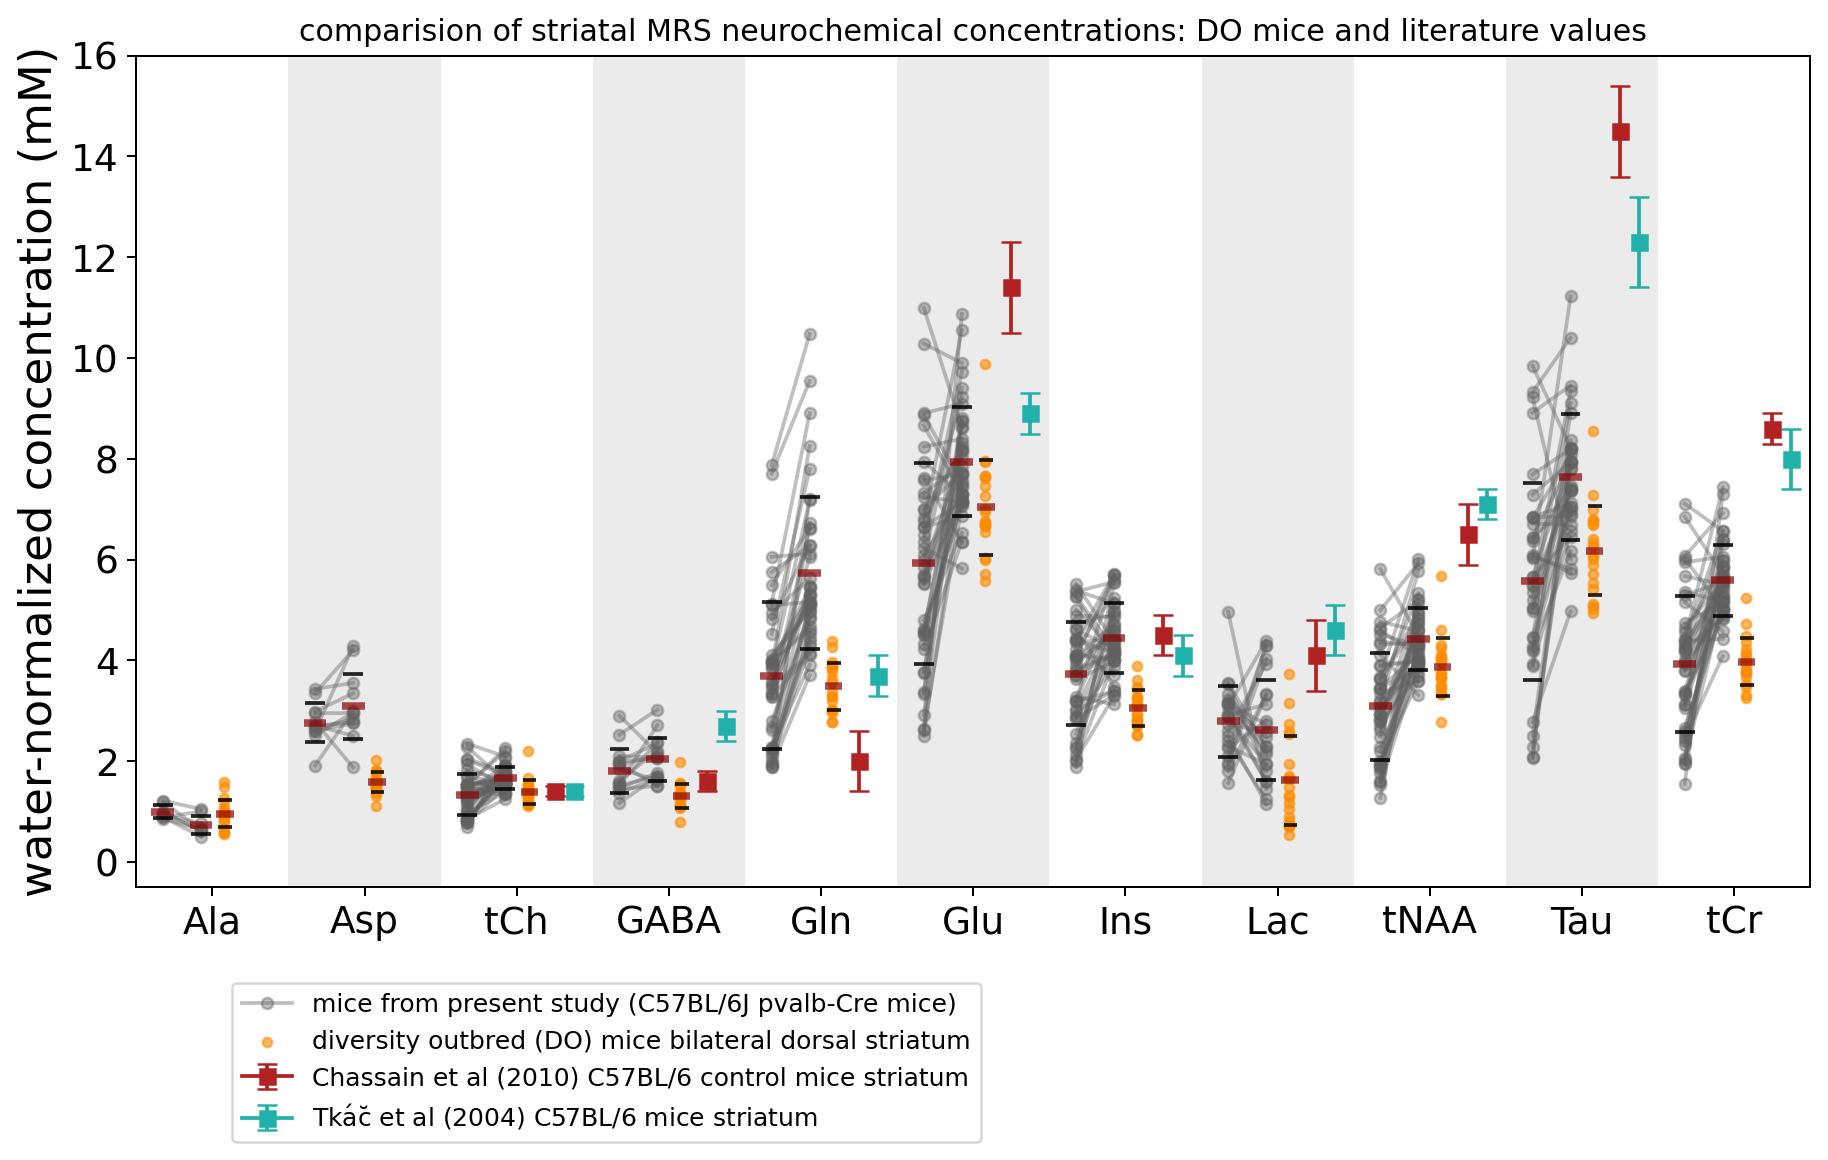

In [17]:
var_list_HP = ['ALA', 'ASP', 'CHO', 'GABA',	'GLN', 'GLU', 'INS', 'Lac', 'NAA', 'Tau', 'tCr']

var_list_CIE = ['Ala_Conc_BL', 'Asp_Conc_BL', 'GPC_p_PCh_Conc_BL', 'GABA_Conc_BL', 'Gln_Conc_BL', 'Glu_Conc_BL',
               'Ins_Conc_BL', 'Lac_Conc_BL', 'NAA_p_NAAG_Conc_BL', 'Tau_Conc_BL', 'Cr_p_PCr_Conc_BL']

var_list_DO = ['Ala_Conc', 'Asp_Conc', 'GPC_p_PCh_Conc', 'GABA_Conc', 'Gln_Conc', 'Glu_Conc',
               'Ins_Conc', 'Lac_Conc', 'NAA_p_NAAG_Conc', 'Tau_Conc', 'Cr_p_PCr_Conc']

var_list_Literature = ['ALA', 'ASP', 'tCho', 'GABA', 'Gln', 'Glu', 'Myo-Ins', 'Lac', 'NAA', 'Tau', 'tCr']

tmp_HP_df = HP_df.loc[(HP_df['Timepoint'] == 'MRS 1') & (HP_df['Brain_region'] == 'Dorsal Striatum')].copy()
tmp_HP_df_VS = HP_df.loc[(HP_df['Timepoint'] == 'MRS 1') & (HP_df['Brain_region'] == 'Ventral Striatum')].copy()

tmp_DO_df_DS = DO_df.loc[DO_df['brain_region'] == 'dorsal_striatum'].copy()


CIE_legend_label = 'mice from present study (C57BL/6J pvalb-Cre mice)'
DO_mice_legend_label = 'diversity outbred (DO) mice bilateral dorsal striatum'
Chassain_legend_label = 'Chassain et al (2010) C57BL/6 control mice striatum'
Tkac_legend_label = r"$\rm Tk\'a\breve c$" + " et al (2004) C57BL/6 mice striatum"


fig_A ,ax_A = plt.subplots(1,1, figsize=(12,6.0))

idx_center = 0.0

for idx_i, var_i in enumerate(var_list_HP):

    CIE_var_name = var_list_CIE[idx_i]
    CIE_SD_name = CIE_var_name.replace('Conc', 'SD')
    DO_var_name = var_list_DO[idx_i]
    Lit_var_name = var_list_Literature[idx_i]

    tmp_CIE_df = CIE_df.loc[CIE_df[CIE_SD_name] < 12.0].copy()
    
    #x_A.scatter(np.repeat(idx_center+0.2, len(tmp_HP_df[var_i])), tmp_HP_df[var_i], color='red')
    #ax_A.scatter(np.repeat(idx_center+0.5, len(tmp_HP_df_VS[var_i])), tmp_HP_df_VS[var_i], color='green')
    
    # ###ax_A.scatter(np.repeat(idx_center-0.5, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_var_name]/0.4378, color='blue')
    # ###ax_A.scatter(np.repeat(idx_center-0.5, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_var_name], color='blue')

    #ax_A.scatter(np.repeat(idx_center-0.5, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_var_name], color='blue')

    for mouse_i in set(tmp_CIE_df['mouse_ID'].values):
        ax_A.plot([idx_center-0.65, idx_center-0.15],
                  [tmp_CIE_df.loc[tmp_CIE_df['mouse_ID']==mouse_i][CIE_var_name], tmp_CIE_df.loc[tmp_CIE_df['mouse_ID']==mouse_i][CIE_var_name[:-3]]],
                  '-o',
                  color='#616161',
                  alpha=0.4, 
                  markersize=4.5,
                  label=CIE_legend_label)
        
        CIE_legend_label = '_nolegend_'
    

    ax_A.scatter(np.repeat(idx_center+0.15, len(tmp_DO_df_DS[DO_var_name])),
                 tmp_DO_df_DS[DO_var_name]*0.4378,
                 color='darkorange',
                 s=14,
                 alpha=0.6,
                 label=DO_mice_legend_label)

    DO_mice_legend_label = '_nolegend_'

    if Lit_var_name not in Lit_Chassain_2010_ctl_df.columns:
        pass
    else:
        ax_A.errorbar(idx_center+0.50,
                      Lit_Chassain_2010_ctl_df[Lit_var_name],
                      yerr=Lit_Chassain_2010_ctl_df[str(Lit_var_name + '_SD')],
                      color='firebrick',
                      marker='s',
                      markersize=6,
                      capsize=4,
                      label=Chassain_legend_label)

        Chassain_legend_label = '_nolegend_'

    if Lit_var_name not in Lit_Tkac_2004_df.columns:
        pass
    else:
        ax_A.errorbar(idx_center+0.75,
                      Lit_Tkac_2004_df[Lit_var_name],
                      yerr=Lit_Tkac_2004_df[str(Lit_var_name + '_SD')],
                      color='lightseagreen',
                      marker='s',
                      markersize=6,
                      capsize=4,
                      label=Tkac_legend_label)

        Tkac_legend_label = '_nolegend_'
                 
    
    #if max(tmp_CIE_df[CIE_var_name]) > 30.0:
    #    print(tmp_CIE_df.loc[tmp_CIE_df[CIE_var_name] > 30])

    t_test_result_A = ttest_ind(tmp_HP_df[var_i], tmp_CIE_df[CIE_var_name])
    print(var_i)
    print(t_test_result_A.pvalue)
    print(' ')

    #ax_A.hlines(np.mean(tmp_HP_df[var_i]), idx_center+0.05, idx_center+0.3, color='k', linewidth=3)
    #ax_A.hlines(np.percentile(tmp_HP_df[var_i], [25,50,75]), idx_center+0.1, idx_center+0.25, color='gray', alpha=0.85)

    ax_A.hlines(np.mean(tmp_CIE_df[CIE_var_name]), idx_center-0.80, idx_center-0.50, color='darkred', linewidth=3, alpha=0.7)
    #ax_A.hlines(np.percentile(tmp_CIE_df[CIE_var_name], [25,50,75]), idx_center-0.78, idx_center-0.52, color='y', alpha=0.85)
    ax_A.hlines((np.mean(tmp_CIE_df[CIE_var_name]) + np.std(tmp_CIE_df[CIE_var_name])), idx_center-0.78, idx_center-0.52, color='k', alpha=0.85)
    ax_A.hlines((np.mean(tmp_CIE_df[CIE_var_name]) - np.std(tmp_CIE_df[CIE_var_name])), idx_center-0.78, idx_center-0.52, color='k', alpha=0.85)

    print(CIE_var_name)
    print('mean conc:')
    print(np.mean(tmp_CIE_df[CIE_var_name]))
    print(' ')
    
    ax_A.hlines(np.mean(tmp_CIE_df[CIE_var_name[:-3]]), idx_center-0.30, idx_center-0.00, color='darkred', linewidth=3, alpha=0.7)
    #ax_A.hlines(np.percentile(tmp_CIE_df[CIE_var_name[:-3]], [25,50,75]), idx_center-0.28, idx_center-0.02, color='y', alpha=0.85)
    ax_A.hlines((np.mean(tmp_CIE_df[CIE_var_name[:-3]]) + np.std(tmp_CIE_df[CIE_var_name[:-3]])), idx_center-0.28, idx_center-0.02, color='k', alpha=0.85)
    ax_A.hlines((np.mean(tmp_CIE_df[CIE_var_name[:-3]]) - np.std(tmp_CIE_df[CIE_var_name[:-3]])), idx_center-0.28, idx_center-0.02, color='k', alpha=0.85)

    #ax_A.hlines(np.mean(tmp_CIE_df[CIE_var_name]/0.4378), idx_center-0.65, idx_center-0.4, color='k', linewidth=3)
    #ax_A.hlines(np.percentile(tmp_CIE_df[CIE_var_name]/0.4378, [25,50,75]), idx_center-0.60, idx_center-0.45, color='gray', alpha=0.85)
    
    #ax_A.hlines(np.mean(tmp_DO_df_DS[DO_var_name]), idx_center-0.35, idx_center-0.1, color='k', linewidth=3)
    #ax_A.hlines(np.percentile(tmp_DO_df_DS[DO_var_name], [25,50,75]), idx_center-0.30, idx_center-0.15, color='gray', alpha=0.85)

    ax_A.hlines(np.mean(tmp_DO_df_DS[DO_var_name]*0.4378), idx_center+0.05, idx_center+0.28, color='darkred', linewidth=3, alpha=0.7)
    #ax_A.hlines(np.percentile(tmp_DO_df_DS[DO_var_name]*0.4378, [25,50,75]), idx_center+0.08, idx_center+0.26, color='y', alpha=0.85)
    ax_A.hlines((np.mean(tmp_DO_df_DS[DO_var_name]*0.4378) + np.std(tmp_DO_df_DS[DO_var_name]*0.4378)), idx_center+0.08, idx_center+0.26, color='k', alpha=0.85)
    ax_A.hlines((np.mean(tmp_DO_df_DS[DO_var_name]*0.4378) - np.std(tmp_DO_df_DS[DO_var_name]*0.4378)), idx_center+0.08, idx_center+0.26, color='k', alpha=0.85)
    

    #ax_A.hlines(np.mean(tmp_HP_df_VS[var_i]), idx_center+0.6, idx_center+0.4, color='k', linewidth=3)
    #ax_A.hlines(np.percentile(tmp_HP_df_VS[var_i], [25,50,75]), idx_center+0.65, idx_center+0.45, color='gray', alpha=0.85)

    idx_center += 2.0

    ax_A.fill_between([1,3], [-1,-1], [50, 50], facecolor='#e6e6e6', zorder=0.5, alpha=0.1)
    ax_A.fill_between([5,7], [-1,-1], [50, 50], facecolor='#e6e6e6', zorder=0.5, alpha=0.1)
    ax_A.fill_between([9,11], [-1,-1], [50, 50], facecolor='#e6e6e6', zorder=0.5, alpha=0.1)
    ax_A.fill_between([13,15], [-1,-1], [50, 50], facecolor='#e6e6e6', zorder=0.5, alpha=0.1)
    ax_A.fill_between([17,19], [-1,-1], [50, 50], facecolor='#e6e6e6', zorder=0.5, alpha=0.1)

x_tick_lab_list =  ['Ala', 'Asp', 'tCh', 'GABA', 'Gln', 'Glu', 'Ins', 'Lac', 'tNAA', 'Tau', 'tCr']
#ax_A.set_xticks(range(0,len(var_list_HP*2), 2), labels=var_list_HP, size=15)
ax_A.set_xticks(range(0,len(var_list_HP*2), 2), labels=x_tick_lab_list, size=15)


#ax_A.set_title('CIE mice (blue) versus DO mice dorsal striatum (orange), HP mice dorsal striatum (red), and HP ventral striatum (green) at baseline')
#ax_A.set_title('CIE mice (blue) versus DO mice dorsal striatum (orange) at baseline')
ax_A.set_title('comparision of striatal MRS neurochemical concentrations: DO mice and literature values')

ax_A.set_ylim(-0.5, 16)
ax_A.set_xlim(-1, 21)

ax_A.tick_params(axis='y', labelsize=15)

ax_A.set_ylabel('water-normalized concentration (mM)', size=18)

ax_A.legend(bbox_to_anchor=(0.05,-0.1), loc='upper left')

plt.show()


### CIE, DO, HPs

ALA
4.16671339768399e-05
 
ASP
0.19487800974176592
 
CHO
5.317002324957748e-18
 
GABA
2.1823673745395474e-05
 
GLN
5.188643653954536e-10
 
GLU
6.166974534510103e-20
 
INS
1.0969818145085646e-12
 
Lac
2.082006480724707e-05
 
NAA
2.944079338323982e-21
 
Tau
1.9224711233073653e-15
 
tCr
4.679635465565444e-18
 


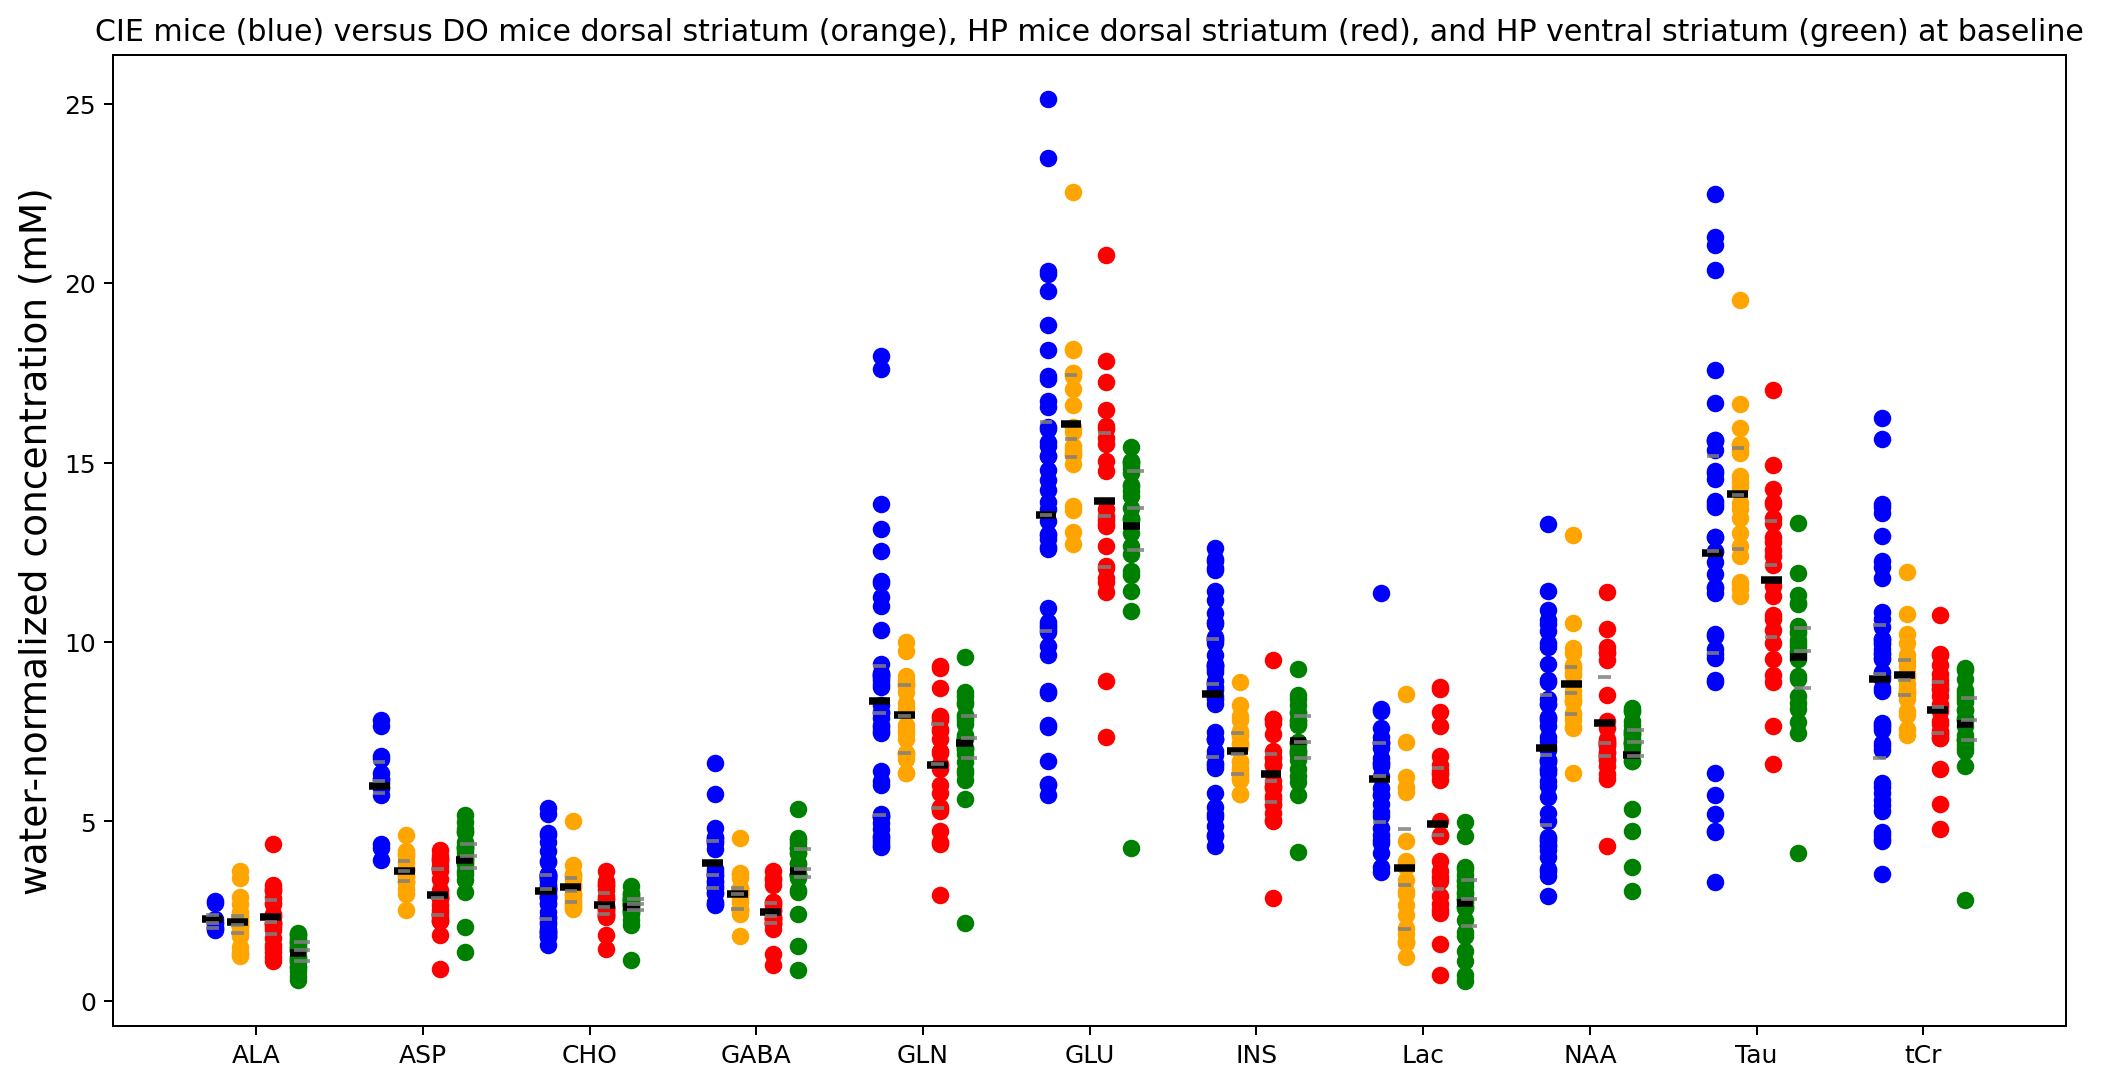

In [18]:
var_list_HP = ['ALA', 'ASP', 'CHO', 'GABA',	'GLN', 'GLU', 'INS', 'Lac', 'NAA', 'Tau', 'tCr']

var_list_CIE = ['Ala_Conc_BL', 'Asp_Conc_BL', 'GPC_p_PCh_Conc_BL', 'GABA_Conc_BL', 'Gln_Conc_BL', 'Glu_Conc_BL',
               'Ins_Conc_BL', 'Lac_Conc_BL', 'NAA_p_NAAG_Conc_BL', 'Tau_Conc_BL', 'Cr_p_PCr_Conc_BL']

var_list_DO = ['Ala_Conc', 'Asp_Conc', 'GPC_p_PCh_Conc', 'GABA_Conc', 'Gln_Conc', 'Glu_Conc',
               'Ins_Conc', 'Lac_Conc', 'NAA_p_NAAG_Conc', 'Tau_Conc', 'Cr_p_PCr_Conc']

tmp_HP_df = HP_df.loc[(HP_df['Timepoint'] == 'MRS 1') & (HP_df['Brain_region'] == 'Dorsal Striatum')].copy()
tmp_HP_df_VS = HP_df.loc[(HP_df['Timepoint'] == 'MRS 1') & (HP_df['Brain_region'] == 'Ventral Striatum')].copy()

tmp_DO_df_DS = DO_df.loc[DO_df['brain_region'] == 'dorsal_striatum'].copy()


fig_A ,ax_A = plt.subplots(1,1, figsize=(14,7.0))

idx_center = 0.0

for idx_i, var_i in enumerate(var_list_HP):

    CIE_var_name = var_list_CIE[idx_i]
    CIE_SD_name = CIE_var_name.replace('Conc', 'SD')
    DO_var_name = var_list_DO[idx_i]

    tmp_CIE_df = CIE_df.loc[CIE_df[CIE_SD_name] < 13.0].copy()
    
    ax_A.scatter(np.repeat(idx_center+0.2, len(tmp_HP_df[var_i])), tmp_HP_df[var_i], color='red')
    ax_A.scatter(np.repeat(idx_center+0.5, len(tmp_HP_df_VS[var_i])), tmp_HP_df_VS[var_i], color='green')
    
    ax_A.scatter(np.repeat(idx_center-0.5, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_var_name]/0.4378, color='blue')
    #ax_A.scatter(np.repeat(idx_center-0.5, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_var_name], color='blue')


    ax_A.scatter(np.repeat(idx_center-0.2, len(tmp_DO_df_DS[DO_var_name])), tmp_DO_df_DS[DO_var_name], color='orange')

    
    #if max(tmp_CIE_df[CIE_var_name]) > 30.0:
    #    print(tmp_CIE_df.loc[tmp_CIE_df[CIE_var_name] > 30])

    t_test_result_A = ttest_ind(tmp_HP_df[var_i], tmp_CIE_df[CIE_var_name])
    print(var_i)
    print(t_test_result_A.pvalue)
    print(' ')

    ax_A.hlines(np.mean(tmp_HP_df[var_i]), idx_center+0.05, idx_center+0.3, color='k', linewidth=3)
    ax_A.hlines(np.percentile(tmp_HP_df[var_i], [25,50,75]), idx_center+0.1, idx_center+0.25, color='gray', alpha=0.85)

    #ax_A.hlines(np.mean(tmp_CIE_df[CIE_var_name]), idx_center-0.65, idx_center-0.4, color='k', linewidth=3)
    #ax_A.hlines(np.percentile(tmp_CIE_df[CIE_var_name], [25,50,75]), idx_center-0.60, idx_center-0.45, color='gray', alpha=0.85)

    ax_A.hlines(np.mean(tmp_CIE_df[CIE_var_name]/0.4378), idx_center-0.65, idx_center-0.4, color='k', linewidth=3)
    ax_A.hlines(np.percentile(tmp_CIE_df[CIE_var_name]/0.4378, [25,50,75]), idx_center-0.60, idx_center-0.45, color='gray', alpha=0.85)
    
    ax_A.hlines(np.mean(tmp_DO_df_DS[DO_var_name]), idx_center-0.35, idx_center-0.1, color='k', linewidth=3)
    ax_A.hlines(np.percentile(tmp_DO_df_DS[DO_var_name], [25,50,75]), idx_center-0.30, idx_center-0.15, color='gray', alpha=0.85)

    ax_A.hlines(np.mean(tmp_HP_df_VS[var_i]), idx_center+0.6, idx_center+0.4, color='k', linewidth=3)
    ax_A.hlines(np.percentile(tmp_HP_df_VS[var_i], [25,50,75]), idx_center+0.65, idx_center+0.45, color='gray', alpha=0.85)

    idx_center += 2.0

ax_A.set_xticks(range(0,len(var_list_HP*2), 2), labels=var_list_HP)

ax_A.set_title('CIE mice (blue) versus DO mice dorsal striatum (orange), HP mice dorsal striatum (red), and HP ventral striatum (green) at baseline')

ax_A.set_ylabel('water-normalized concentration (mM)', size=15)

plt.show()
    

ALA
0.0038163290068797284
 
ASP
6.4872641330731175e-06
 
CHO
0.05752377650629705
 
GABA
0.009033097611856845
 
GLN
0.025601853866218032
 
GLU
4.8580614973683555e-05
 
INS
6.3491346479969806e-06
 
Lac
0.967421750650608
 
NAA
3.924024048613649e-11
 
Tau
0.0005892282216286391
 
tCr
nan
 


C:\Users\baetscer\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


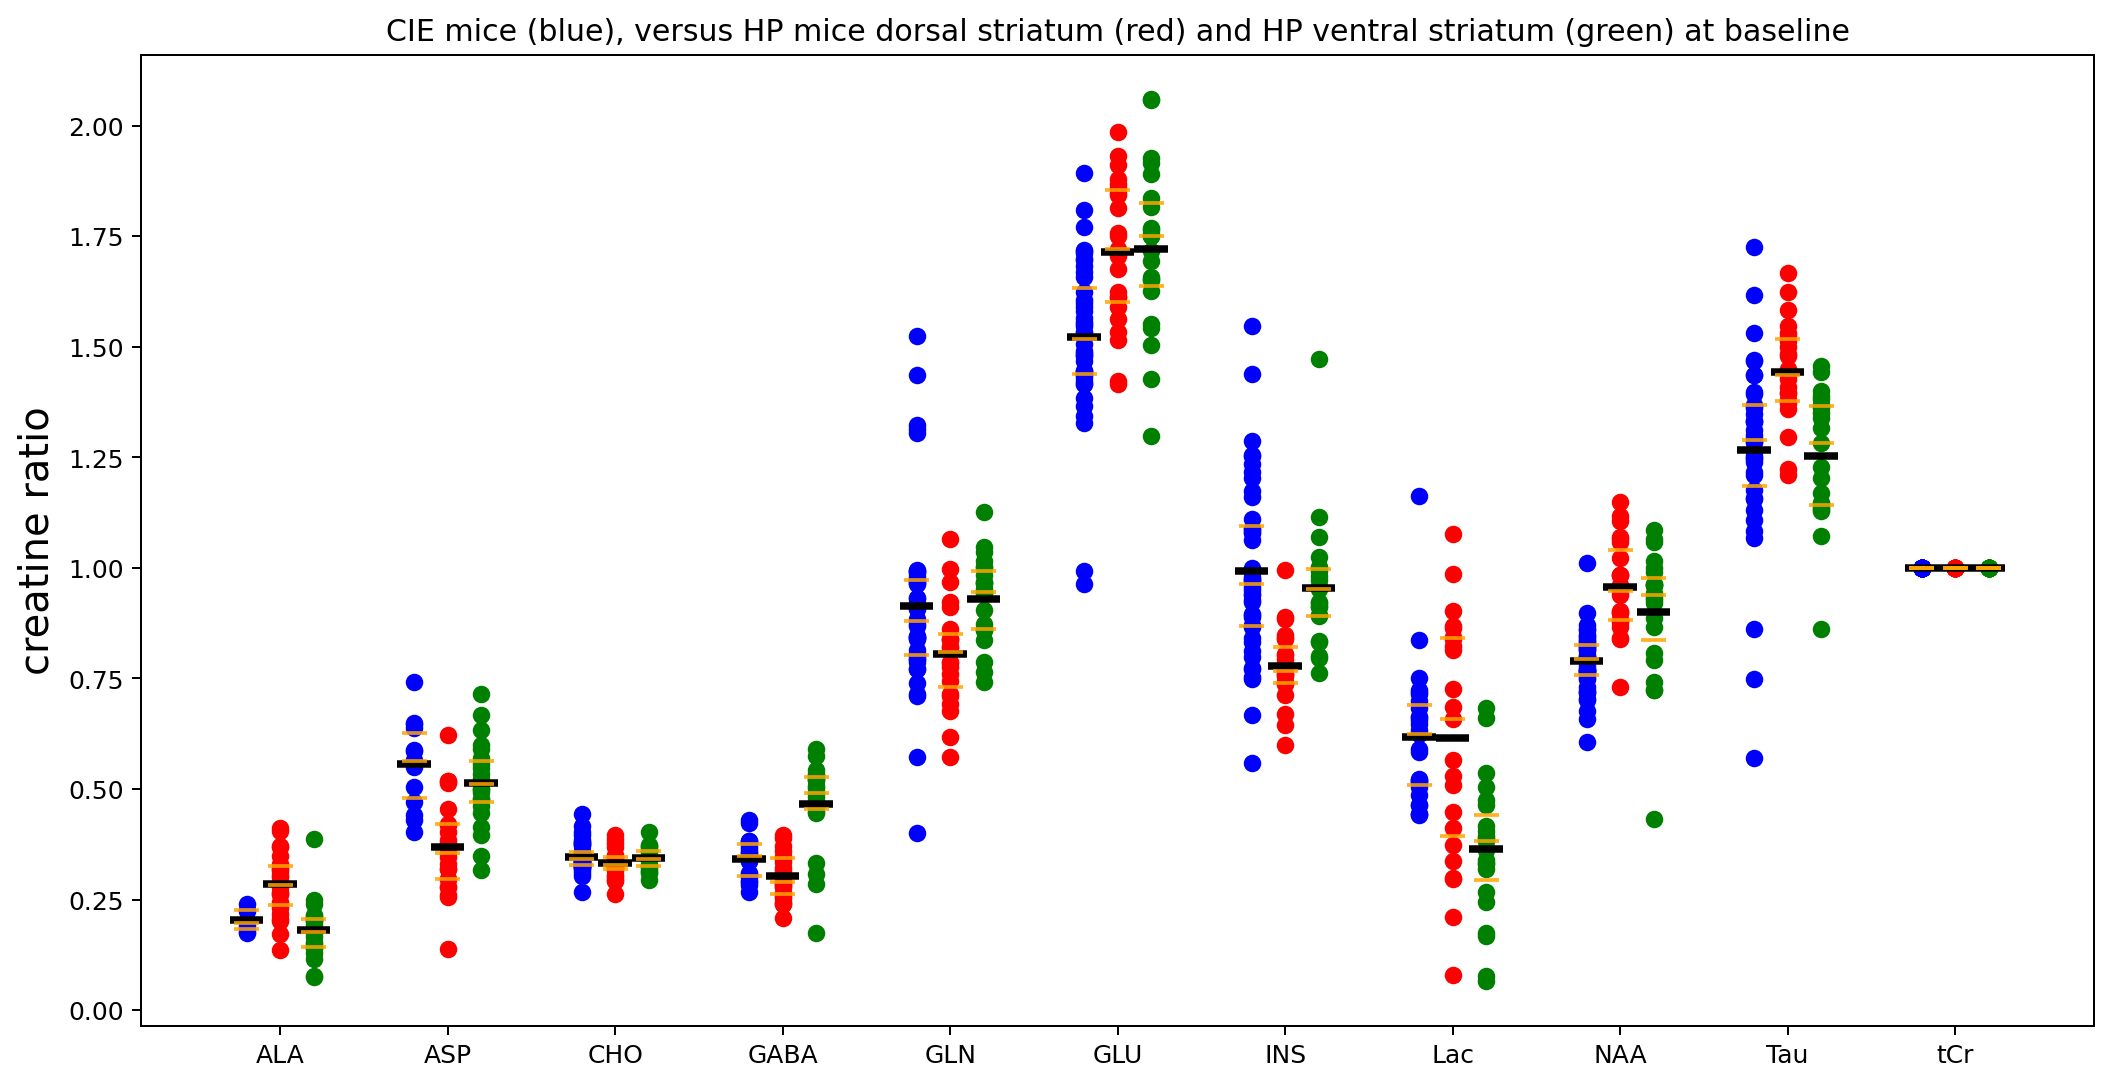

In [19]:


fig_B ,ax_B = plt.subplots(1,1, figsize=(14,7.0))

idx_center = 0.0

for idx_i, var_i in enumerate(var_list_HP):

    CIE_var_name = var_list_CIE[idx_i]
    CIE_SD_name = CIE_var_name.replace('Conc', 'SD')
    CIE_over_Cr_name = CIE_var_name.replace('Conc', 'over_Cr')

    tmp_CIE_df = CIE_df.loc[CIE_df[CIE_SD_name] < 13.0].copy()
    
    ax_B.scatter(np.repeat(idx_center+0.0, len(tmp_HP_df[var_i])), (tmp_HP_df[var_i] / tmp_HP_df['tCr']), color='red')
    ax_B.scatter(np.repeat(idx_center+0.4, len(tmp_HP_df_VS[var_i])), (tmp_HP_df_VS[var_i] / tmp_HP_df_VS['tCr']), color='green')
    
    ax_B.scatter(np.repeat(idx_center-0.4, len(tmp_CIE_df[CIE_var_name])), tmp_CIE_df[CIE_over_Cr_name], color='blue')

    t_test_result_B = ttest_ind((tmp_HP_df[var_i] / tmp_HP_df['tCr']), tmp_CIE_df[CIE_over_Cr_name])
    print(var_i)
    print(t_test_result_B.pvalue)
    print(' ')

    ax_B.hlines(np.mean((tmp_HP_df[var_i] / tmp_HP_df['tCr'])), idx_center-0.2, idx_center+0.2, color='k', linewidth=3)
    ax_B.hlines(np.percentile((tmp_HP_df[var_i] / tmp_HP_df['tCr']), [25,50,75]), idx_center-0.15, idx_center+0.15, color='orange', alpha=0.85)

    ax_B.hlines(np.mean(tmp_CIE_df[CIE_over_Cr_name]), idx_center-0.60, idx_center-0.2, color='k', linewidth=3)
    ax_B.hlines(np.percentile(tmp_CIE_df[CIE_over_Cr_name], [25,50,75]), idx_center-0.55, idx_center-0.25, color='orange', alpha=0.85)

    ax_B.hlines(np.mean(tmp_HP_df_VS[var_i] / tmp_HP_df_VS['tCr']), idx_center+0.6, idx_center+0.2, color='k', linewidth=3)
    ax_B.hlines(np.percentile((tmp_HP_df_VS[var_i] / tmp_HP_df_VS['tCr']), [25,50,75]), idx_center+0.55, idx_center+0.25, color='orange', alpha=0.85)

    idx_center += 2.0

ax_B.set_xticks(range(0,len(var_list_HP*2), 2), labels=var_list_HP)

ax_B.set_title('CIE mice (blue), versus HP mice dorsal striatum (red) and HP ventral striatum (green) at baseline')

ax_B.set_ylabel('creatine ratio', size=16)

plt.show()